In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
DATASET_PATH = r"C:\Users\User\Desktop\BRAIN_PROJECT\data image"

In [3]:
#  Image Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=20, 
    width_shift_range=0.2, 
    height_shift_range=0.2, 
    shear_range=0.2, 
    zoom_range=0.2, 
    horizontal_flip=True, 
    validation_split=0.1  # 10% of training data for validation
)


In [4]:
#  Training data
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH + "\\Training",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 5143 images belonging to 4 classes.


In [5]:
#  Validation data
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH + "\\Training",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 569 images belonging to 4 classes.


In [6]:
#  Test data
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    DATASET_PATH + "\\Testing",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)


Found 1311 images belonging to 4 classes.


In [7]:
#  CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(512,(3,3),activation="relu"),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 classes: Glioma, Meningioma, Pituitary, No Tumor
])

c:\Users\User\Desktop\BRAIN_PROJECT\env1\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
#  Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
model.fit(train_generator, validation_data=val_generator, epochs=50)

Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 90s 550ms/step - accuracy: 0.5174 - loss: 1.0574 - val_accuracy: 0.5448 - val_loss: 1.0853
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 85s 530ms/step - accuracy: 0.6593 - loss: 0.8285 - val_accuracy: 0.6239 - val_loss: 0.8921
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 85s 528ms/step - accuracy: 0.7095 - loss: 0.6992 - val_accuracy: 0.7030 - val_loss: 0.7525
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 85s 530ms/step - accuracy: 0.7352 - loss: 0.6621 - val_accuracy: 0.6344 - val_loss: 0.8679
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 84s 521ms/step - accuracy: 0.7754 - loss: 0.5661 - val_accuracy: 0.7733 - val_loss: 0.6463
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 85s 529ms/step - accuracy: 0.8122 - loss: 0.4983 - val_accuracy: 0.8067 - val_loss: 0.5838
Epoch 7/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 89s 551ms/step - accuracy: 0.8205 - loss: 0.4631 - val_accuracy: 0.7557 - val_loss: 0.6022
Epoch 8/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 99s 612ms/step - accuracy: 0.8285 - loss: 0

In [10]:
# img_path = r"C:\Users\User\Desktop\BRAIN_PROJECT\data image\glioma_exmp.jpg"
img_path = r"C:\Users\User\Desktop\BRAIN_PROJECT\data image\meningloma.jpg"
# img_path = r"C:\Users\User\Desktop\BRAIN_PROJECT\data image\no_tumer.jpg"
# img_path = r"C:\Users\User\Desktop\BRAIN_PROJECT\data image\pitutary_2.jpg"
# img_path = r"C:\Users\User\Desktop\BRAIN_PROJECT\data image\pitutary_exmp.jpg"

In [11]:
class_labels = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step

Predicted Class: Meningioma
Confidence: 93.79%


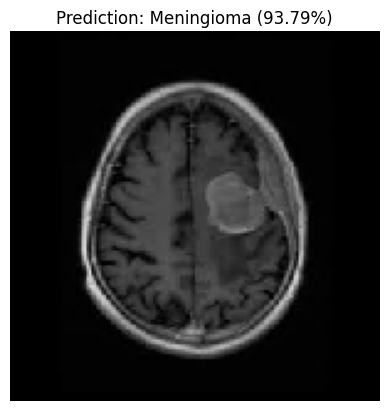

In [12]:
# Load and preprocess image
img = load_img(img_path, target_size=(150, 150))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)
predicted_index = np.argmax(prediction, axis=1)[0]
predicted_label = class_labels[predicted_index]
confidence = np.max(prediction) * 100

print(f"\nPredicted Class: {predicted_label}")
print(f"Confidence: {confidence:.2f}%")


plt.imshow(img)
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)")
plt.axis("off")
plt.show()